## Face Detection & Attribute Prediction Pipeline

This notebook combines **face detection** with our trained **multi-task learning model** to create an end-to-end system that:

1. **Detects** faces in images using Haar Cascade classifiers (from OpenCV)
2. **Crops** detected face regions
3. **Predicts** age, gender, and ethnicity for each detected face
4. **Visualizes** results with bounding boxes and labels overlaid on the original image

### Key Difference from Inference Notebook:
- **Inference notebook**: Works on pre-cropped faces (you provide clean face images)
- **Detection System**: Works on any image, automatically finds and analyzes all faces

### Workflow:
1. ✅ Load the trained model and Haar Cascade face detector
2. ✅ Load an image containing one or more faces
3. ✅ Detect all faces in the image
4. ✅ Run predictions on each detected face
5. ✅ Draw boxes and labels on the image
6. ✅ Display the annotated result

## Step 1️⃣: Import Libraries

- **OpenCV (cv2)**: For face detection and image manipulation
- **PyTorch**: For running our trained model
- **Matplotlib & PIL**: For image processing and visualization

In [1]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
from model import FaceAnalysisModel

## Step 2️⃣: Load Model & Initialize Face Detector

1. **Load the trained multi-task model** from `face_cnn.pth`
2. **Initialize Haar Cascade classifier**: A pre-trained detector for frontal faces provided by OpenCV
3. **Define label mappings**: Human-readable names for predictions

### About Haar Cascades:
Haar Cascade is a classical machine learning approach for object detection:
- Fast and real-time capable
- Works well for frontal faces
- Pre-trained classifiers are built into OpenCV
- Not as accurate as deep learning methods but sufficient for this use case

### The `full_pipeline_predict()` Function:
This is the main function that orchestrates the entire pipeline:
1. Reads the image using OpenCV
2. Converts to grayscale for face detection
3. Detects all faces using Haar Cascade
4. For each detected face:
   - Crops the face region
   - Resizes to 48×48 pixels (model input size)
   - Runs predictions with the trained model
   - Extracts age, gender, and ethnicity
5. Draws green boxes around faces and labels with predictions
6. Displays the annotated image

In [3]:
# 1. Setup Device and Load Model
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = FaceAnalysisModel(backbone_requires_grad=False).to(device)
model.load_state_dict(torch.load("face_cnn.pth", map_location=device))
model.eval()

# 2. Initialize OpenCV Face Detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 3. Define Labels
genders = ["Male", "Female"]
ethnicities = ["White", "Black", "Asian", "Indian", "Others"]

def full_pipeline_predict(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not load image.")
        return
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    for (x, y, w, h) in faces:
        # 1. Crop and Transform
        face_roi = gray[y:y+h, x:x+w]
        face_pil = Image.fromarray(face_roi)
        
        transform = T.Compose([
            T.Resize((48, 48)),
            T.ToTensor(),
        ])
        face_tensor = transform(face_pil).unsqueeze(0).to(device)
        
        # 2. Predict
        with torch.no_grad():
            out_age, out_gender, out_ethnicity = model(face_tensor)
        
        age = out_age.item()
        gender = genders[out_gender.argmax(1).item()]
        eth = ethnicities[out_ethnicity.argmax(1).item()]
        
        # 3. Draw high-visibility box and label
        # Green box
        cv2.rectangle(rgb_img, (x, y), (x+w, y+h), (0, 255, 0), 4)
        
        # Background for text (makes it readable on any background)
        label = f"{int(age)}yrs, {gender}, {eth}"
        cv2.putText(rgb_img, label, (x, y-15), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(rgb_img)
    plt.axis('off')
    plt.show()

## Step 3️⃣: Test the Full Pipeline

Now let's run the complete face detection and attribute prediction pipeline on a test image.

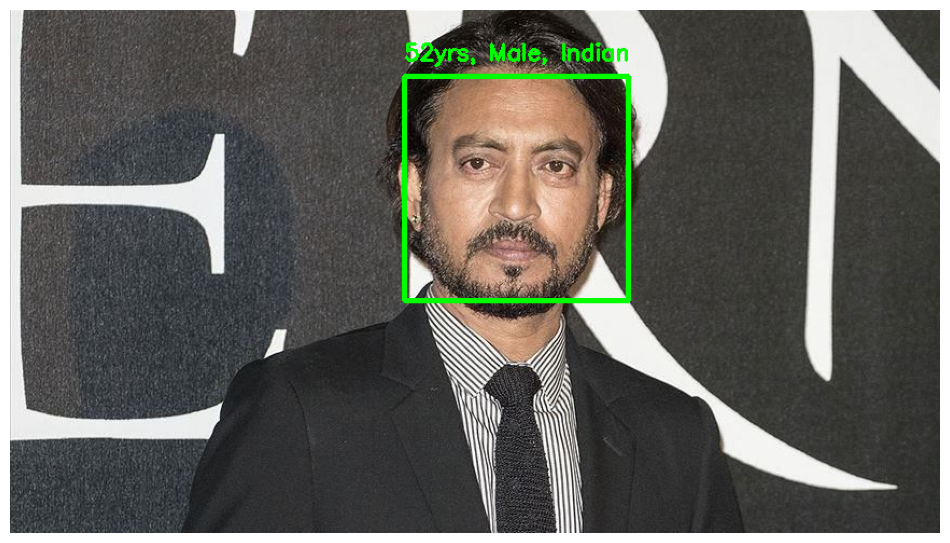

In [4]:
# Test it out!
full_pipeline_predict("./testing_data/Irrfan_khan.jpg")

## Step 4️⃣: Face Detection Visualization (Optional)

This helper function demonstrates just the face detection part without predictions. Useful for:
- Debugging detection issues
- Understanding where the model thinks faces are
- Adjusting detection parameters if needed

The `detectMultiScale()` parameters:
- `1.1`: Scale factor (how much the image size is reduced at each iteration)
- `4`: Minimum number of neighbors (higher = fewer false positives but might miss faces)

In [5]:
def visualize_detection(image_path):
    # 1. Load the real image
    img = cv2.imread(image_path)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Detect the faces
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    # 3. Draw the rectangles
    for (x, y, w, h) in faces:
        # cv2.rectangle(image, start_point, end_point, color, thickness)
        cv2.rectangle(rgb_img, (x, y), (x + w, y + h), (0, 255, 0), 5)
        
        # We can also add a small label above the box
        cv2.putText(rgb_img, "Scanning Face...", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    plt.imshow(rgb_img)
    plt.axis('off')
    plt.show()

## Summary

### How the System Works:
```
Input Image → Face Detection (Haar Cascade) → Crop Face Regions → 
Preprocess (Resize to 48×48) → Multi-Task Model → 
Extract Predictions → Draw Boxes & Labels → Display Result
```

### Key Components:

**1. Face Detection (Haar Cascade)**
- Classical ML approach, very fast
- Works well for frontal faces
- Can have false positives on similar patterns
- Adjustable sensitivity via `detectMultiScale()` parameters

**2. Multi-Task Model**
- Trained on 48×48 grayscale images
- Three simultaneous predictions: Age, Gender, Ethnicity
- Shared feature extraction → task-specific heads
- Balanced loss weighting for optimal performance

**3. Visualization**
- Green boxes: Detected face regions
- Green text: Predicted attributes
- Clear, readable format for quick assessment